Câu 1: Cho data mx48 -> Giảm chiều dữ liệu để còn 95% cần thiết (truy vấn vào componemt explain) + vẽ hình 

Câu 2: Đọc hiểu document kernel PCA (phi tuyến )

Cau3: PCA là tuyến tính. Nếu phi tuyến tìm các pp xử lý (MDS, IsoMap) -> cho ví dụ các sử dụng 

In [2]:
import numpy as np
import pandas as pd
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("clean_feature.csv")
df = df.dropna()
df = df.drop_duplicates()
df["datetime"] = pd.to_datetime(df["Day"]) + pd.to_timedelta(df["hour"], unit="h")
print(df["ServiceID"].unique().shape)  


(12,)


In [4]:
def query_interval(df, t_datetime, T):
    start = t_datetime - pd.Timedelta(hours=T)
    return df[(df["datetime"] >= start) & (df["datetime"] <= t_datetime)]


In [5]:
#query
t = pd.to_datetime("2023-07-27 18:00:00")
result = query_interval(df, t, 12)
result = result.sort_index()
print(result.shape)

(693, 9)


In [6]:
#groupby
features = result.groupby(["datetime", "ServiceID"]).agg(
        total_calls=("count", "sum"), # a> Tổng số lần gọi
        total_success=("passed", "sum"), # b> Tổng số lần gọi thành công
        mean_exec_time=("period", "mean"), # c> Trị trung bình thời gian thực thi
        mean_data_usage=("data", "mean") # d> Trị trung bình dữ liệu sử dụng
    )
matrix = features.unstack(level="ServiceID", fill_value=0)
matrix = matrix.sort_index(axis=1, level=1)
matrix.to_csv("feature.csv", index=False)
matrix

,mean_data_usage,mean_exec_time,total_calls,total_success,mean_data_usage,mean_exec_time,total_calls,total_success,mean_data_usage,mean_exec_time,...,total_calls,total_success,mean_data_usage,mean_exec_time,total_calls,total_success,mean_data_usage,mean_exec_time,total_calls,total_success
ServiceID,0,0,0,0,1,1,1,1,2,2,...,8,8,10,10,10,10,11,11,11,11
datetime,,,,,,,,,,,,,,,,,,,,,
2023-07-27 06:00:00,0.000000,0.0,0,0,623.500000,62.0,2,2,582.241510,63.853785,...,7,6,378355.325000,0.0,120,120,873.046977,63.000000,28155,28155
2023-07-27 07:00:00,0.000000,0.0,0,0,493.989595,62.0,187,187,601.752269,63.949111,...,5,5,378355.395000,0.0,120,120,928.508802,63.000000,46135,46135
2023-07-27 08:00:00,1539.777778,63.0,7,7,462.861153,62.0,577,577,624.835269,63.999436,...,6,6,378354.830575,0.0,120,120,929.086420,63.000000,69951,69951
2023-07-27 09:00:00,1517.906250,63.0,22,22,556.287882,62.0,433,433,621.066943,63.950774,...,17,17,378354.691505,0.0,120,120,942.409857,63.000000,83892,83892
2023-07-27 10:00:00,1890.900000,63.0,10,10,426.753175,62.0,1658,1658,619.292998,63.956362,...,31,31,378354.795525,0.0,120,120,958.386481,63.000000,89333,89333
2023-07-27 11:00:00,1143.800000,63.0,11,11,538.484222,62.0,182,182,623.067411,63.952872,...,18,18,378354.854440,0.0,120,120,937.626937,63.000000,82455,82455
2023-07-27 12:00:00,1891.666667,63.0,4,4,513.886310,62.0,30,30,611.088263,63.949545,...,4,4,378354.920280,0.0,120,120,917.772682,63.000000,70621,70621
2023-07-27 13:00:00,2153.250000,63.0,4,4,588.948204,62.0,343,343,615.677958,63.966780,...,22,22,378354.831101,0.0,120,120,931.690648,62.999985,74829,74829


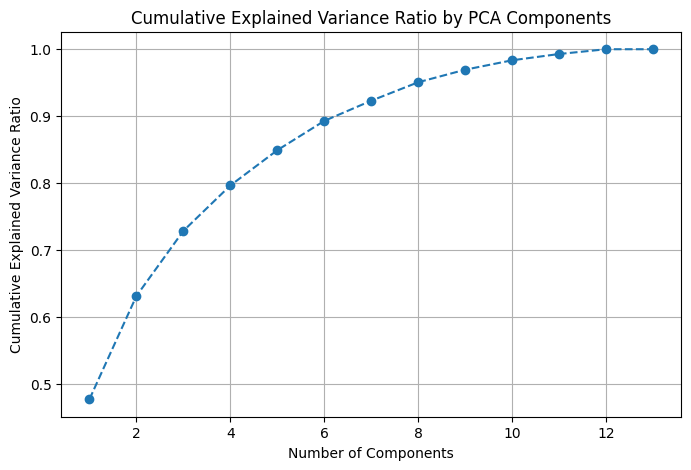

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
X_scaler = StandardScaler().fit_transform(matrix)       # X: m x 48
pca = PCA(svd_solver='full').fit(X_scaler)
eigvals = pca.explained_variance_            
evr = pca.explained_variance_ratio_         
cum_evr = np.cumsum(evr)                     # tỉ lệ phương sai tích lũy
# Vẽ biểu đồ tỉ lệ phương sai tích lũy
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance Ratio by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid()


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


scaler = StandardScaler()
Xz = scaler.fit_transform(matrix)

pca = PCA(n_components=8, svd_solver='full')
Z = pca.fit_transform(Xz)

print("EVR tích lũy với 8 PCs:", pca.explained_variance_ratio_.cumsum()[-1])

df_pca = pd.DataFrame(Z, columns=[f"PC{i+1}" for i in range(8)])
df_pca


EVR tích lũy với 8 PCs: 0.9506518112578914


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-10.772258,1.037840,1.703314,0.527685,1.117038,-1.006979,-0.022344,-0.618115
1,-6.909385,1.455998,0.942877,0.446332,-2.064328,0.960636,0.110694,0.500187
2,0.696529,2.451169,-1.267372,-0.946096,-1.075191,-0.746373,-1.163230,1.877823
3,2.761152,2.269527,0.875918,-2.678881,1.376815,0.404768,1.608761,-0.120331
4,4.320238,2.420656,-0.336674,-0.071983,-2.592552,-1.402653,-0.456934,-2.267696
5,2.208197,1.157649,-0.711164,-1.429776,0.838160,0.072494,0.086701,0.745238
6,-1.813944,-0.522144,-2.037470,-1.306696,-0.306556,2.036063,1.107253,-0.489321
7,1.026447,0.673274,-2.420455,2.108290,1.060765,-1.704565,0.124152,1.093884
8,3.370295,0.791897,-0.265139,3.893488,0.746667,0.962992,1.292916,-0.421648
9,3.801515,-1.471270,3.126822,0.930462,-0.882895,2.071294,-1.154641,0.795759
